In [1]:
print("[INFO] Starting script...")
print("[INFO] Importing libraries...")

import os
import json
import ipaddress
import numpy as np
import pandas as pd
import dns.resolver
import geoip2.database
import dns.reversename
import matplotlib.pyplot as plt

print("[INFO] Libraries imported.")
print("[INFO] Setting up directories and files...")

dataset_id = 8

script_directory = os.getcwd()
datasets_directory = os.path.join(script_directory, "datasets")
databases_directory = os.path.join(script_directory, "databases")
output_directory = os.path.join(script_directory, "output")

if not os.path.exists(output_directory):
    os.makedirs(output_directory)

normal_flows_file = os.path.join(datasets_directory, f"data{dataset_id}.parquet")
anomalous_flows_file = os.path.join(datasets_directory, f"test{dataset_id}.parquet")

geoASN = geoip2.database.Reader(
    os.path.join(script_directory, "databases/geolite2-asn.mmdb")
)
geoCC = geoip2.database.Reader(
    os.path.join(script_directory, "databases/geolite2-country.mmdb")
)

normal_data = pd.read_parquet(normal_flows_file)
anomalous_data = pd.read_parquet(anomalous_flows_file)

print("[INFO] Directories and files set up.")

[INFO] Starting script...
[INFO] Importing libraries...
[INFO] Libraries imported.
[INFO] Setting up directories and files...
[INFO] Directories and files set up.


# Chapter 0. Project Overview

This report documents the process of analysing non-anomalous traffic flows in a corporate network to define a baseline for normal network behavior. The primary objective is to develop and implement Security Information and Event Management (SIEM) rules capable of detecting anomalous network behaviors that may indicate compromised devices or malicious activities within a corporate environment.

The main challenge we're tackling is straightforward: how do you detect malicious activity in a network when you don't know what "normal" looks like?
We began by analyzing dataset 8 (data8.parquet), which contains a full day's worth of network flows that have been verified as legitimate traffic. This gave us the foundation to understand typical communication patterns, bandwidth usage, and the usual destinations that devices in this network connect to.

With this baseline established, we developed specific detection rules targeting five key areas where attackers commonly operate: internal botnet coordination, data theft through HTTPS or DNS channels, command-and-control communications hidden in DNS traffic, connections to unusual external locations, and suspicious activity from external users accessing corporate services.
The final step involved putting these rules to the test using two additional datasets that potentially contain malicious activity. This allowed us to validate whether our detection logic actually works in practice and identify specific IP addresses showing signs of compromise.

From a technical standpoint, we relied heavily on Python and pandas for processing the parquet-formatted network flow logs. The GeoLite2 databases were used for understanding the geographic and organizational context of external connections, helping distinguish between legitimate international traffic and potentially suspicious communications to unexpected locations.


# Chapter 1. Normal Traffic Analysis

Analyzing the normal traffic of the dataset without any anomalies is essential to establish a baseline for network behavior. This allows us to identify deviations from the norm, which may indicate potential security threats. This chapter is dedicated to exploring the normal traffic patterns, including protocol and port usage, flow counts per protocol:port, flow counts per IP, identifying the servers and clients, and other important metrics.

## Subchapter 1.1. Protocol and Port Usage

Protocols never come alone, they always come associated with a port. Performing this combined analysis allows us to understand the most common protocols and ports used in the dataset.

proto  port
tcp    443     765644
udp    53      102788
dtype: int64


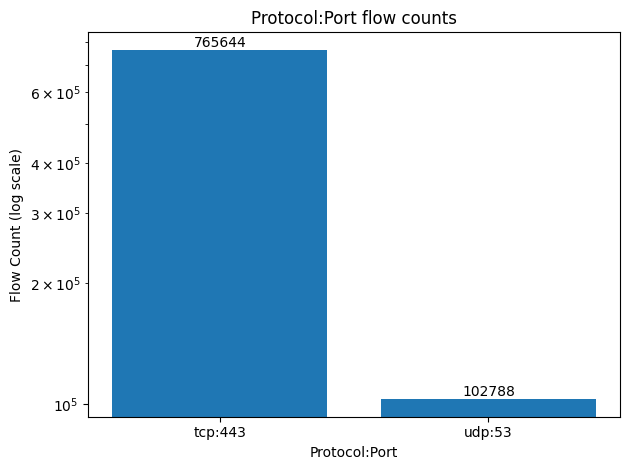

In [2]:
n_protocol_port_counts = normal_data.groupby(["proto", "port"]).size()
print(n_protocol_port_counts)

labels = [f"{proto}:{port}" for proto, port in n_protocol_port_counts.index]

plt.title("Protocol:Port flow counts")
bars = plt.bar(labels, n_protocol_port_counts.values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
    )

plt.xlabel("Protocol:Port")
plt.ylabel("Flow Count (log scale)")
plt.yscale("log")
plt.tight_layout()
plt.show()

Given this plot, we can see that the only protocols used in the non-anomalous dataset are TCP:443 and UDP:53, which are commonly used for secure web traffic and DNS queries, respectively. This indicates that the dataset consists of web traffic and DNS requests, which is typical for many network environments. Any significant deviations from this pattern, or the appearance of a new protocol:port combination in the anomalous dataset could indicate potential security threats or unusual network behavior.

## Subchapter 1.2. Bandwidth Usage

Bandwidth usage is a critical metric for understanding what amount of data is being transferred over the network when in normal operation. This analysis helps to identify the volume of traffic and can highlight any unusual spikes which may indicate the presence of security threats.

From this analysis, we can observe that the majority of the bandwidth is consumed by TCP:443, which is expected as it is commonly used for web traffic. The UDP:53 protocol, used for DNS queries, consumes significantly less bandwidth, which is also typical since DNS requests are generally small in size.

Top protocol:port combinations by total traffic:
  proto_port    up_gb    down_gb   total_gb
0    tcp:443  8.11965  75.202540  83.322190
1     udp:53  0.01913   0.043881   0.063011


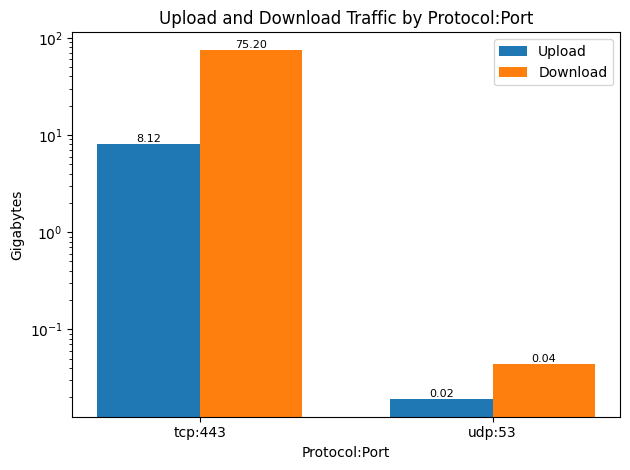

In [3]:
n_protocol_port_traffic = (
    normal_data.groupby(["proto", "port"])
    .agg({"up_bytes": "sum", "down_bytes": "sum"})
    .reset_index()
)

# Convert bytes to gigabytes
n_protocol_port_traffic["up_gb"] = n_protocol_port_traffic["up_bytes"] / (1024**3)
n_protocol_port_traffic["down_gb"] = n_protocol_port_traffic["down_bytes"] / (1024**3)
n_protocol_port_traffic["total_gb"] = (
    n_protocol_port_traffic["up_gb"] + n_protocol_port_traffic["down_gb"]
)

n_protocol_port_traffic["proto_port"] = (
    n_protocol_port_traffic["proto"] + ":" + n_protocol_port_traffic["port"].astype(str)
)

n_protocol_port_traffic = n_protocol_port_traffic.sort_values(
    "total_gb", ascending=False
)

print("Top protocol:port combinations by total traffic:")
print(n_protocol_port_traffic[["proto_port", "up_gb", "down_gb", "total_gb"]].head(10))

fig, ax = plt.subplots()
x = range(len(n_protocol_port_traffic))
width = 0.35

# Create bars for upload and download
upload_bars = ax.bar(
    [i - width / 2 for i in x], n_protocol_port_traffic["up_gb"], width, label="Upload"
)
download_bars = ax.bar(
    [i + width / 2 for i in x],
    n_protocol_port_traffic["down_gb"],
    width,
    label="Download",
)

for bar in upload_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

for bar in download_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.set_xlabel("Protocol:Port")
ax.set_ylabel("Gigabytes")
ax.set_title("Upload and Download Traffic by Protocol:Port")
ax.set_xticks(x)
ax.set_xticklabels(n_protocol_port_traffic["proto_port"], ha="center")
ax.legend()
ax.set_yscale("log")

plt.tight_layout()
plt.show()

## Subchapter 1.3. Contacted Countries

Defining normally contacted countries is crucial for understanding the geographical distribution of network traffic. This helps in identifying potential security threats, such as unexpected traffic to countries that are not typically associated with the organization's operations.

dst_cc
US       276527
LOCAL    255173
PT       230134
NL        17142
DE        15883
GB         8448
ES         4080
BR         3770
IE         1155
HK          441
IN          396
AU          299
SG          290
IT          253
KR          202
CA          188
SE          167
JP          163
ZA          128
FR          116
CH          113
BH           97
IL           77
AE           75
SA           51
NO           36
CN           31
BE           29
ID           19
MY           12
NZ            9
TH            7
DK            5
CL            5
TW            4
OM            3
FI            2
Name: count, dtype: int64
Private IP contacted by clients:
['192.168.108.240' '192.168.108.231' '192.168.108.233' '192.168.108.234'
 '192.168.108.237']


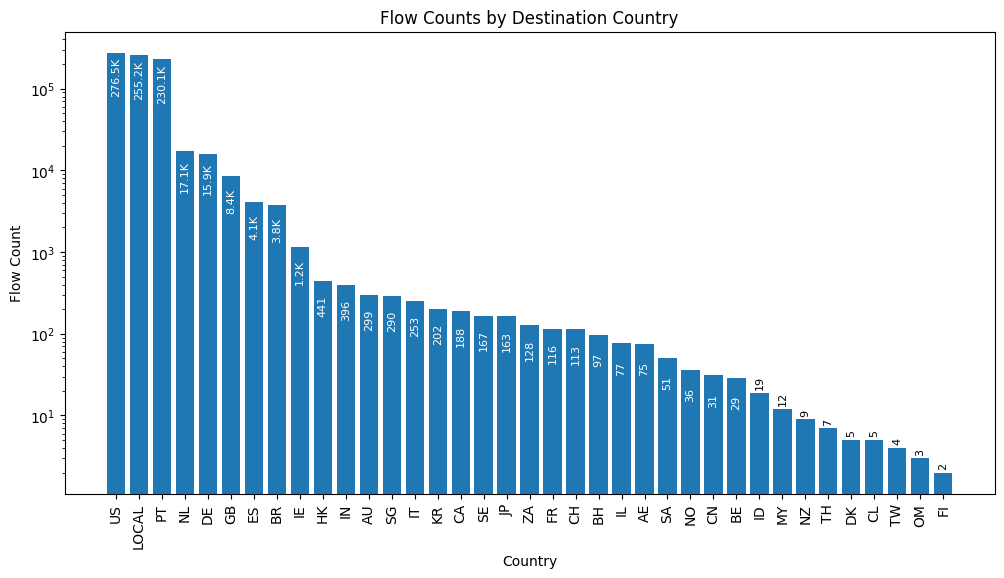

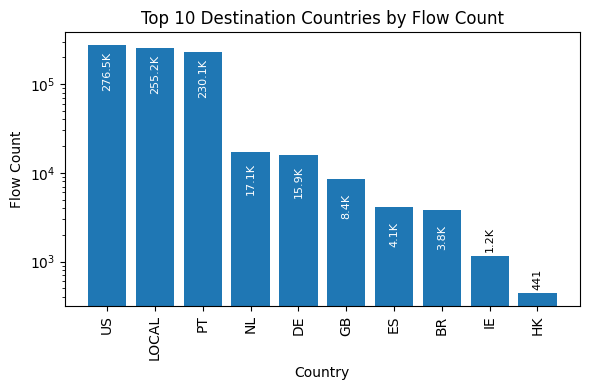

In [4]:
def get_country_code(ip):
    try:
        ip = ipaddress.ip_address(ip)
        if ip.is_private:
            return "LOCAL"
        else:
            return geoCC.country(ip).country.iso_code
    except:
        return "UNKNOWN"


normal_data["dst_cc"] = normal_data["dst_ip"].apply(lambda x: get_country_code(x))
n_country_counts = normal_data["dst_cc"].value_counts()
print(n_country_counts)

# Get the contacted private IP addresses list
print("Private IP contacted by clients:")
print(normal_data[normal_data["dst_cc"] == "LOCAL"]["dst_ip"].unique())

plt.figure(figsize=(12, 6))
bars = plt.bar(n_country_counts.index, n_country_counts.values)


def format_number(num):
    if num >= 1000:
        return f"{num/1000:.1f}K"
    return str(int(num))


for bar in bars:
    height = bar.get_height()
    text = format_number(height)

    # For very small bars, put text above
    if height < 20:
        y_pos = height * 1.1  # Above the bar
        color = "black"
        va = "bottom"
    else:
        y_pos = height / 2  # Inside the bar
        color = "white"
        va = "center"

    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        y_pos,
        text,
        ha="center",
        va=va,
        fontsize=8,
        rotation=90,
        color=color,
    )

plt.title("Flow Counts by Destination Country")
plt.xlabel("Country")
plt.ylabel("Flow Count")
plt.xticks(rotation=90)
plt.yscale("log")
plt.show()

nhead = 10
n_country_counts = n_country_counts.head(nhead)
plt.figure(figsize=(6, 4))
bars = plt.bar(n_country_counts.index, n_country_counts.values)

for bar in bars:
    height = bar.get_height()
    text = format_number(height)

    # For very small bars, put text above
    if height < 2000:
        y_pos = height * 1.1  # Above the bar
        color = "black"
        va = "bottom"
    else:
        y_pos = height / 2  # Inside the bar
        color = "white"
        va = "center"

    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        y_pos,
        text,
        ha="center",
        va=va,
        fontsize=8,
        rotation=90,
        color=color,
    )
plt.title(f"Top {nhead} Destination Countries by Flow Count")
plt.xlabel("Country")
plt.ylabel("Flow Count")
plt.xticks(rotation=90)
plt.yscale("log")
plt.tight_layout()
plt.show()

From this analysis, we can determine that the majority of the traffic is directed towards the United States, which is expected for many organizations. It is important to clarify that "LOCAL" refers to the local network and not a specific country, and was included in the analysis to account for internal traffic within the organization. Later on, this information could be used to differentiate between internal company servers and normal clients.

In total, 36 different countries were contacted by the clients (US, PT, NL, DE, GB, ES, BR, IE, HK, IN, AU, SG, IT, KR, CA, SE, JP, ZA, FR, CH, BH, IL, AE, SA, NO, CN, BE, ID, MY, NZ, TH, DK, CL, TW, OM, FI).

## Subchapter 1.4. Contacted Autonomous Systems

Let's move from analyzing the implicated countries to a more granular inspection of the contributing Autonomous Systems (AS).

     dst_asn                                        dst_asn_org   count
0     1897.0                             Nos Comunicacoes, S.A.   68628
1     1930.0       Fundacao para a Ciencia e a Tecnologia, I.P.    5845
2     3243.0         Servicos De Comunicacoes E Multimedia S.A.   38027
3     7018.0                                      ATT-INTERNET4     111
4     8068.0                        MICROSOFT-CORP-MSN-AS-BLOCK   23816
5     8069.0                        MICROSOFT-CORP-MSN-AS-BLOCK     215
6     8070.0                        MICROSOFT-CORP-MSN-AS-BLOCK    2200
7     8075.0                        MICROSOFT-CORP-MSN-AS-BLOCK   29088
8     8987.0                   Amazon Data Services Ireland Ltd     153
9    13335.0                                      CLOUDFLARENET   52902
10   13414.0                                            TWITTER     337
11   14061.0                                   DIGITALOCEAN-ASN    2808
12   14618.0                                         AMAZON-AES 

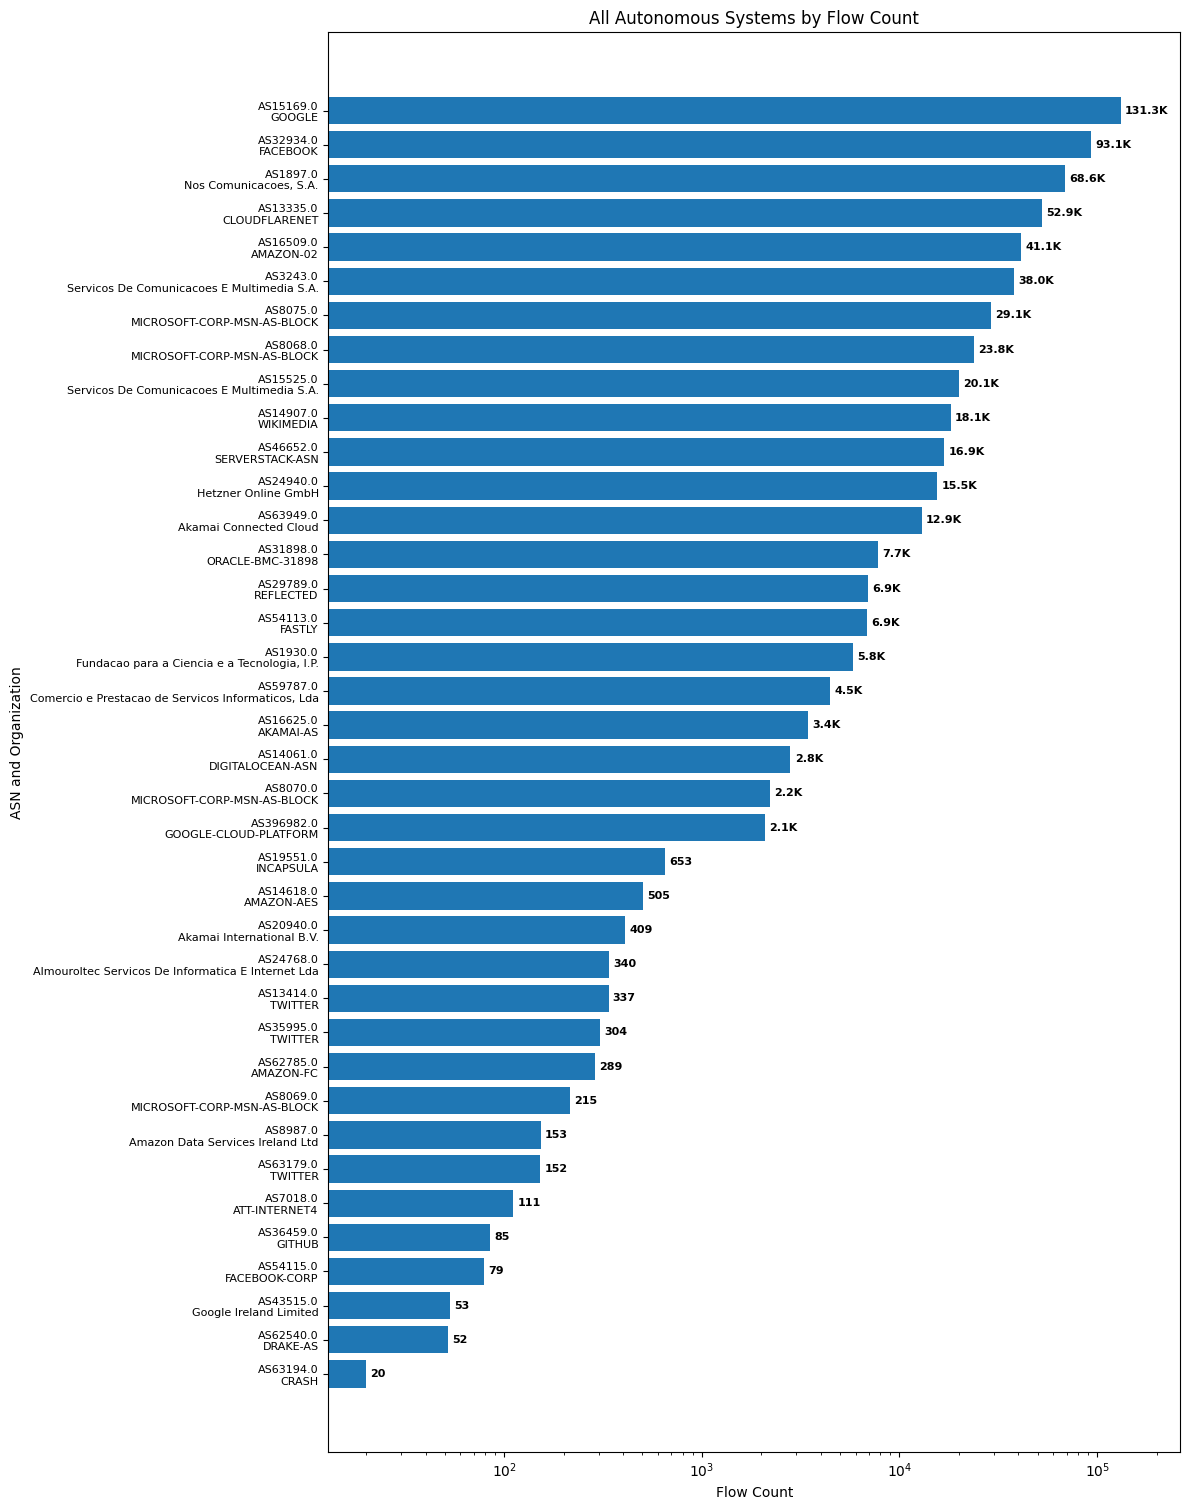

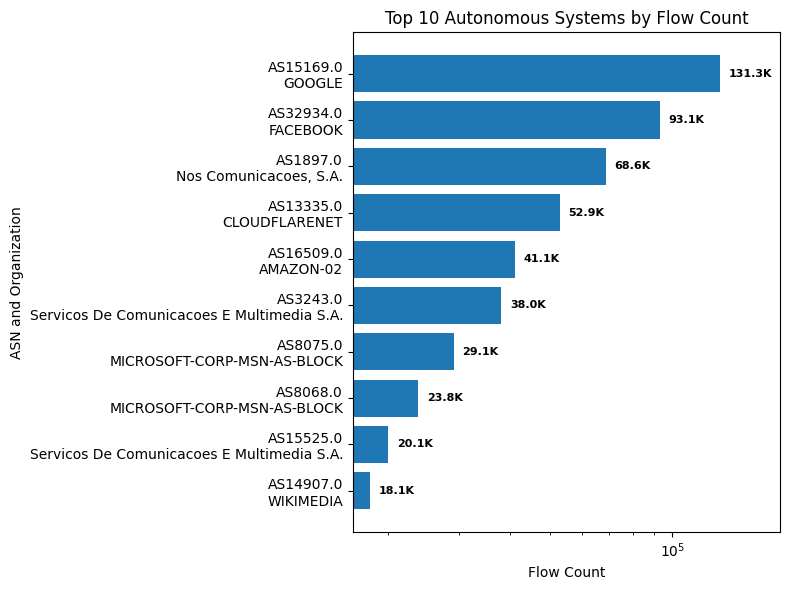

In [5]:
def get_asn(ip):
    try:
        ip = ipaddress.ip_address(ip)
        if ip.is_private:
            return (None, "LOCAL")
        else:
            return (
                geoASN.asn(ip).autonomous_system_number,
                geoASN.asn(ip).autonomous_system_organization,
            )
    except:
        return (None, "UNKNOWN")

asn_data = normal_data["dst_ip"].apply(get_asn)
normal_data["dst_asn"], normal_data["dst_asn_org"] = zip(*asn_data)
n_asn_counts = (
    normal_data.groupby(["dst_asn", "dst_asn_org"]).size().reset_index(name="count")
)
print(n_asn_counts)

asn_counts = n_asn_counts.sort_values("count", ascending=True)
asn_counts["label"] = asn_counts.apply(
    lambda row: (
        f"AS{row['dst_asn']}\n{row['dst_asn_org']}"
        if row["dst_asn"] is not None
        else row["dst_asn_org"]
    ),
    axis=1,
)

num_entries = len(asn_counts)
fig_height = max(12, num_entries * 0.4)  # At least 12, or 0.4 inches per entry

plt.figure(figsize=(12, fig_height))
bars = plt.barh(range(len(asn_counts)), asn_counts["count"])

def format_number(num):
    if num >= 1000:
        return f"{num/1000:.1f}K"
    return str(int(num))

for i, bar in enumerate(bars):
    width = bar.get_width()
    text = format_number(width)
    x_pos = width * 1.05
    color = "black"
    ha = "left"
    plt.text(
        x_pos,
        bar.get_y() + bar.get_height() / 2.0,
        text,
        ha=ha,
        va="center",
        fontsize=8,
        rotation=0,
        color=color,
        weight="bold",
    )

plt.ylabel("ASN and Organization")
plt.xlabel("Flow Count")
plt.title("All Autonomous Systems by Flow Count")
plt.yticks(range(len(asn_counts)), asn_counts["label"], fontsize=8)
plt.subplots_adjust(left=0.3)

plt.xscale("log")
plt.xlim(right=asn_counts["count"].max() * 2)
plt.tight_layout()
plt.show()

nhead = 10
asn_counts_top = n_asn_counts.sort_values("count", ascending=False).head(nhead)
asn_counts_top["label"] = asn_counts_top.apply(
    lambda row: (
        f"AS{row['dst_asn']}\n{row['dst_asn_org']}"
        if row["dst_asn"] is not None
        else row["dst_asn_org"]
    ),
    axis=1,
)

plt.figure(figsize=(8, 6))
bars = plt.barh(range(len(asn_counts_top)), asn_counts_top["count"])

for i, bar in enumerate(bars):
    width = bar.get_width()
    text = format_number(width)
    x_pos = width * 1.05
    color = "black"
    ha = "left"
    plt.text(
        x_pos,
        bar.get_y() + bar.get_height() / 2.0,
        text,
        ha=ha,
        va="center",
        fontsize=8,
        rotation=0,
        color=color,
        weight="bold",
    )

plt.ylabel("ASN and Organization")
plt.xlabel("Flow Count")
plt.title(f"Top {nhead} Autonomous Systems by Flow Count")
plt.yticks(range(len(asn_counts_top)), asn_counts_top["label"])
plt.xscale("log")
plt.xlim(right=asn_counts_top["count"].max() * 1.4)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

From this analysis, we can see that the majority of the traffic is associated with AS15169 (Google), which is expected for many organizations that rely on Google services. The presence of other ASes, such as AS16509 (Amazon-02) and AS32934 (Facebook), indicates that there may be legitimate business operations with these companies.

In total, 37 different ASes were contacted, which is a relatively small number considering the size of the dataset. This suggests that the network traffic is primarily directed towards a few major service providers. New ASes that were not previously identified in the normal traffic analysis may indicate potential security threats, and should be investigated further.

## Subchapter 1.5 Internal Server/Client Identification

The dataset contains a mix of internal servers and clients, which we need to differentiate for further analysis and they are different in terms of traffic patterns such as bandwidth usage, number of flows, and frequency of communication. We know that the source IPs of the flows are uniquely from local IP addresses, while the destination IPs can be either local or external. This means that when a source IP communicates with a local destination IP, the local destination IP is likely an internal server.
Our investigation reveals that there are only 5 unique local destination IPs, which are likely internal servers due to the traffic nature (protocol:port combination). Aggregating the protocol:port to each individual IP, we can predict what services are running on each server:

In [6]:
n_private_dst_data = normal_data[
    normal_data["dst_ip"].apply(lambda x: ipaddress.ip_address(x).is_private)
]

# Create protocol:port combination first, then group
n_private_dst_data_with_combo = n_private_dst_data.copy()
n_private_dst_data_with_combo["proto_port"] = (
    n_private_dst_data_with_combo["proto"]
    + ":"
    + n_private_dst_data_with_combo["port"].astype(str)
)

private_dst_summary = (
    n_private_dst_data_with_combo.groupby("dst_ip")
    .agg({"proto_port": lambda x: sorted(set(x)), "dst_ip": "size"})
    .rename(
        columns={"proto_port": "protocol_port_combinations", "dst_ip": "flow_count"}
    )
    .sort_values("flow_count", ascending=False)
)

print("[INFO] Private destination IPs and flow count:")
n_server_ips = []
for ip, row in private_dst_summary.iterrows():
    protocols = ", ".join(row["protocol_port_combinations"])
    n_server_ips.append(ip)
    print(f"{ip:<15} | {row['flow_count']:<6} flows | {protocols}")

n_server_flows = normal_data[normal_data["src_ip"].isin(n_server_ips)]
print("[INFO] Flows from servers:", n_server_flows.shape[0])
n_client_flows = normal_data[~normal_data["src_ip"].isin(n_server_ips)]
print("[INFO] Flows from clients:", n_client_flows.shape[0])

[INFO] Private destination IPs and flow count:
192.168.108.234 | 51465  flows | tcp:443
192.168.108.240 | 51417  flows | udp:53
192.168.108.233 | 51371  flows | udp:53
192.168.108.231 | 50596  flows | tcp:443
192.168.108.237 | 50324  flows | tcp:443
[INFO] Flows from servers: 0
[INFO] Flows from clients: 868432


| Servers IP Address | Flow Count | Protocol:Port | Services     |
|--------------------|------------|---------------|--------------|
| 192.168.108.234    | 51465      | tcp:443       | HTTPS        |
| 192.168.108.240    | 51417      | udp:53        | DNS          |
| 192.168.108.233    | 51371      | udp:53        | DNS          |
| 192.168.108.231    | 50596      | tcp:443       | HTTPS        |
| 192.168.108.237    | 50324      | tcp:443       | HTTPS        |

Knowing the servers, by exclusion, we can identify the clients as the remaining source IPs in the dataset and perform a traffic analysis on them. Our results show that the servers never initiate communication to the clients or external IPs and clients never communicate between them.

## Subchapter 1.6. Individual Client Traffic Patterns

Different end users (identified by the src_ip) have different needs and usage patterns. To better detect anomalies, we opted to analyze the traffic patterns of each individual client. This allows us to establish a baseline for each client, which can help in identifying deviations from their normal behavior. If the baseline was established globally, it would be difficult to detect anomalies for individual clients, as their usage patterns may vary significantly.

The metrics we decided to include on the client baseline dataset were:
- src_ip: the identification of the client;
- tot_flows: number of flows initiated by the client;
- avg_flows_per_minute: the average number of flows made in 1 minute;
- tot_up_traffic: total number of uploaded bytes
- tot_down_traffic: total number of downloaded bytes
- contacted_countries: list of countries contacted by the client
- contacted _asns: list of AS numbers contacted by the client
- contacted_private_ip: list of devices on the local network contacted by the client
- protocol_ports: list of protocol:port the client used

In [7]:
print("[INFO] Calculating baseline for each client...")

# Convert timestamp to minutes for flow frequency calculation
n_client_flows_with_minutes = n_client_flows.copy()
n_client_flows_with_minutes['minute'] = n_client_flows_with_minutes['timestamp'] // 6000  # 1 minute = 6000 * (1/100 seconds)

baseline_data = []

for src_ip in n_client_flows['src_ip'].unique():
    client_data = n_client_flows_with_minutes[n_client_flows_with_minutes['src_ip'] == src_ip]
    
    # Basic traffic metrics
    tot_flows = len(client_data)
    tot_up_traffic = client_data['up_bytes'].sum()
    tot_down_traffic = client_data['down_bytes'].sum()
    
    # Calculate average flows per minute
    active_minutes = client_data['minute'].nunique()
    avg_flows_per_minute = tot_flows / active_minutes if active_minutes > 0 else 0
    
    # Get complete list of contacted countries (remove None values)
    contacted_countries = sorted([cc for cc in client_data['dst_cc'].unique() if cc is not None])
    
    # Get complete list of contacted ASNs (remove NaN values)
    contacted_asns = sorted([int(asn) for asn in client_data['dst_asn'].dropna().unique()])
    
    # Get complete list of contacted private IPs
    private_ips = client_data[client_data['dst_ip'].apply(lambda x: ipaddress.ip_address(x).is_private)]['dst_ip'].unique()
    contacted_private_ip = sorted(private_ips.tolist())
    
    # Get complete list of protocol:port combinations used
    protocol_ports = sorted((client_data['proto'] + ':' + client_data['port'].astype(str)).unique().tolist())
    
    baseline_data.append({
        'src_ip': src_ip,
        'tot_flows': tot_flows,
        'avg_flows_per_minute': round(avg_flows_per_minute, 2),
        'tot_up_traffic': tot_up_traffic,
        'tot_down_traffic': tot_down_traffic,
        'contacted_countries': contacted_countries,
        'contacted_asns': contacted_asns,
        'contacted_private_ip': contacted_private_ip,
        'protocol_ports': protocol_ports
    })

n_client_baseline = pd.DataFrame(baseline_data)

print(f"[INFO] Baseline calculated for {len(n_client_baseline)} clients")
print("[INFO] Sample of client baseline:")
print(n_client_baseline.head())

# Display summary statistics
print("\n[INFO] Baseline Summary Statistics:")
print(f"Total number of clients: {len(n_client_baseline)}")
print(f"Average flows per client: {n_client_baseline['tot_flows'].mean():.2f}")
print(f"Average flows per minute per client: {n_client_baseline['avg_flows_per_minute'].mean():.2f}")
print(f"Average upload traffic per client: {n_client_baseline['tot_up_traffic'].mean():.2f} bytes")
print(f"Average download traffic per client: {n_client_baseline['tot_down_traffic'].mean():.2f} bytes")

# Prepare data for CSV export (convert lists to strings for human readability)
print("[INFO] Preparing data for CSV export...")

n_client_baseline_csv = n_client_baseline.copy()
n_client_baseline_csv['contacted_countries'] = n_client_baseline_csv['contacted_countries'].apply(lambda x: ';'.join(map(str, x)))
n_client_baseline_csv['contacted_asns'] = n_client_baseline_csv['contacted_asns'].apply(lambda x: ';'.join(map(str, x)))
n_client_baseline_csv['contacted_private_ip'] = n_client_baseline_csv['contacted_private_ip'].apply(lambda x: ';'.join(map(str, x)))
n_client_baseline_csv['protocol_ports'] = n_client_baseline_csv['protocol_ports'].apply(lambda x: ';'.join(map(str, x)))

# Save to CSV for human inspection
baseline_file = os.path.join(output_directory, f"client_baseline_{dataset_id}.csv")
n_client_baseline_csv.to_csv(baseline_file, index=False)
print(f"[INFO] Client baseline saved to {baseline_file}")

# Display a few sample records for verification
print("\n[INFO] Sample baseline records (first 3 clients):")
for i in range(min(3, len(n_client_baseline_csv))):
    print(f"\nClient {i+1} ({n_client_baseline_csv.iloc[i]['src_ip']}):")
    print(f"  Total flows: {n_client_baseline_csv.iloc[i]['tot_flows']}")
    print(f"  Avg flows/min: {n_client_baseline_csv.iloc[i]['avg_flows_per_minute']}")
    print(f"  Upload traffic: {n_client_baseline_csv.iloc[i]['tot_up_traffic']:,} bytes")
    print(f"  Download traffic: {n_client_baseline_csv.iloc[i]['tot_down_traffic']:,} bytes")
    print(f"  Countries: {n_client_baseline_csv.iloc[i]['contacted_countries']}")
    print(f"  ASNs: {n_client_baseline_csv.iloc[i]['contacted_asns']}")
    print(f"  Private IPs: {n_client_baseline_csv.iloc[i]['contacted_private_ip']}")
    print(f"  Protocols: {n_client_baseline_csv.iloc[i]['protocol_ports']}")

print("\n[INFO] Client baseline analysis complete!")

[INFO] Calculating baseline for each client...
[INFO] Baseline calculated for 197 clients
[INFO] Sample of client baseline:
            src_ip  tot_flows  avg_flows_per_minute  tot_up_traffic  \
0  192.168.108.148       7149                 18.33        71546576   
1  192.168.108.167       7346                 19.38        74010242   
2  192.168.108.193       6679                 18.81        66133160   
3  192.168.108.198       4186                 18.04        42741195   
4  192.168.108.203       7706                 18.57        77614790   

   tot_down_traffic                                contacted_countries  \
0         675371876  [BR, DE, ES, GB, IE, IL, LOCAL, NL, PT, SE, SG...   
1         668431920  [AE, AU, BR, DE, DK, ES, FR, GB, IE, IL, LOCAL...   
2         624266478  [AU, BR, CA, DE, ES, GB, IE, IN, LOCAL, NL, PT...   
3         388032635  [BR, CA, DE, ES, GB, IE, IT, KR, LOCAL, NL, PT...   
4         735724024  [BR, DE, ES, GB, HK, ID, IE, IN, KR, LOCAL, NL...   

    

The output of this analysis consists on a dataset that contains the traffic patterns of each individual client. Additionally, we also saved the dataset as a CSV file for easy visualization.

## Subchapter 1.7. Individual Internal Server Traffic Patterns

We have already identified the internal servers in subchapter 1.5 and we already know that they only communicate on a specific protocol:port combination with clients and never with each other nor with external IPs. Thus, we have already established a baseline for the internal servers. Even for number of flows, as they never initiate communication, the number of flows should always be 0.

# Chapter 2. Defining SIEM Rules

In this chapter, we will define the SIEM rules based on the analysis of normal traffic patterns. The goal is to create rules that can detect anomalies in network behavior, which may indicate ~malicious activities. We will focus on five key areas where attackers commonly operate: internal botnet coordination, data theft through HTTPS or DNS channels, command-and-control communications hidden in DNS traffic, connections to unusual external locations, and suspicious activity from external users accessing corporate services.

In [8]:
from siemrules import *

## Subchapter 2.1. Protocol and Port Usage

As established in chapter 1.1, normal traffic only uses TCP:443 and UDP:53. The implemented SIEM rule detects protocol:port anomalies through three main checks:
- New Protocol:Port Detection: Any protocol:port combination not seen in baseline traffic triggers a critical alert, indicating potential malicious activity like backdoor communications.
- Traffic Volume Monitoring: For existing combinations, the rule monitors flow count changes:
  - Critical alerts for ≥10% increases (potential DDoS, data exfiltration)
  - Warning alerts for ≥5% increases or ≥10% decreases (unusual activity patterns)
- Missing Protocol:Port Detection: Warning alerts when expected combinations are absent, indicating possible service disruptions.

This rule provides rapid identification of network behavior anomalies and enables targeted investigation of suspicious sources. This rule’s implementation is present on Appendix A.

In [9]:
a_protocol_port_counts = anomalous_data.groupby(["proto", "port"]).size()
check_protocol_port_anomalies(n_protocol_port_counts, a_protocol_port_counts)

[INFO] Running SIEM Rule: Protocol:Port Anomaly Detection
[CRIT] New protocol:port combination detected: udp:443 (56 flows)
[WARN] Warning increase in tcp:443 traffic: 6.6% increase (765644 -> 816047 flows)
[CRIT] Critical increase in udp:53 traffic: 112.8% increase (102788 -> 218737 flows)
[INFO] Total alerts generated: 3


The output of this SIEM rule indicates that a new protocol:port combination was detected (udp:443), which was not present in the normal traffic analysis. Also, a critical alert was triggered due to a significant increase in the number of flows for udp:53. A warning alert was triggered due to a increase in the number of flows for tcp:443, which is not significant enough to trigger a critical alert.

## Subchapter 2.2. Bandwidth Usage

As established in chapter 1.2, normal traffic shows TCP:443 consuming the majority of bandwidth while UDP:53 consumes significantly less. The implemented SIEM rule detects bandwidth anomalies through three main checks:

- New Protocol:Port Detection: Any protocol:port combination with bandwidth usage not seen in baseline traffic triggers a critical alert, indicating potential malicious activity like data exfiltration channels or backdoor communications.
- Bandwidth Volume Monitoring: For existing combinations, the rule monitors upload and download traffic changes separately:
    - Critical alerts for ≥50% increases (potential data exfiltration, large file transfers, DDoS amplification)
    - Warning alerts for ≥20% increases or ≥20% decreases (unusual bandwidth consumption patterns)
- Missing Protocol:Port Detection: Warning alerts when expected combinations are absent in bandwidth data, indicating possible service disruptions or traffic redirection.

This rule enables detection of suspicious bandwidth consumption (abnormal download/upload patterns) that may indicate compromised devices conducting unauthorized activities. As this is a global rule, applyed to the entire dataset, in order to avoid false positives, we set the thresholds to be higher than the ones used in the protocol:port usage rule because we expect that the bandwidth usage may vary more significantly across the dataset while protocol:port usage should be more stable. This rule's implementation is present on Appendix B.

In [10]:
check_bandwidth_anomalies(normal_data, anomalous_data)

[INFO] Running SIEM Rule: Bandwidth Usage Anomaly Detection
[CRIT] New protocol:port combination with bandwidth: udp:443 (Up: 10,335,546,443 bytes, Down: 125,888,132 bytes)
[CRIT] Critical increase in udp:53 upload traffic: 112.9% increase (20,540,743 -> 43,730,391 bytes)
[CRIT] Critical increase in udp:53 download traffic: 113.2% increase (47,116,369 -> 100,440,886 bytes)
[INFO] Total bandwidth alerts generated: 3


The report of this SIEM rule identified a new protocol:port combination (udp:443) with bandwidth usage not seen in baseline traffic, triggering a critical alert. Additionally, two critical alerts were triggered due to a significant increase in the upload and download traffic for udp:53.

By just running these two SIEM rules, we can already see that the test dataset contains some anomalies that were not present in the normal traffic analysis. This indicates that the dataset may contain malicious activity, which we will further investigate in the next chapters.

## Subchapter 2.3. Contacted Contries

As established in chapter 1.3, non-anomalous dataset has 36 different destination countries with the majority directed towards the United States, followed by Portugal, Netherlands, and other legitimate business destinations. The implemented SIEM rule detects geographical anomalies through three main checks:

- New Country Detection: Any country not seen in baseline traffic triggers a critical alert, indicating potential malicious activity like connections to suspicious jurisdictions.
- Traffic Volume Monitoring: For existing countries, the rule monitors flow count changes:
    - Critical alerts for ≥50% increases (potential data exfiltration to specific regions, botnet communications)
    - Warning alerts for ≥30% increases or ≥30% decreases (geographical traffic pattern shifts)
- Missing Country Detection: Warning alerts when expected countries are absent, indicating possible service disruptions, or changes in business operations:
    - Critical alerts for high traffic countries that are no longer contacted (≥1000 flows)
    - Warning alerts for medium traffic countries that are no longer contacted (≥100 flows)
    - Low alerts for low traffic countries that are no longer contacted (<100 flows)

This rule enables the detection of suspicious international communications, data exfiltration to unexpected geographical locations, and changes in traffic distribution patterns that may indicate compromised devices or malicious activities. As this is a global rule applied to the entire dataset, we set higher thresholds. This rule's implementation is present on Appendix C.

In [11]:
if 'dst_cc' not in anomalous_data.columns:
    anomalous_data['dst_cc'] = anomalous_data['dst_ip'].apply(lambda x: get_country_code(x))
    
check_contacted_countries_anomalies(normal_data, anomalous_data)

[INFO] Running SIEM Rule: Contacted Countries Anomaly Detection
[CRIT] New country contacted: MX (7 flows)
[CRIT] New country contacted: RU (2622 flows)
[CRIT] New country contacted: PL (2 flows)
[CRIT] New country contacted: IR (442 flows)
[CRIT] Significant increase in LOCAL traffic: 50.1% increase (255173 -> 383016 flows)
[WARN] Significant decrease in IT traffic: -36.8% decrease (253 -> 160 flows)
[CRIT] Significant increase in CA traffic: 58.0% increase (188 -> 297 flows)
[CRIT] Significant increase in FR traffic: 67.2% increase (116 -> 194 flows)
[WARN] Significant decrease in BH traffic: -38.1% decrease (97 -> 60 flows)
[WARN] Significant decrease in NO traffic: -44.4% decrease (36 -> 20 flows)
[CRIT] Significant increase in CN traffic: 3932.3% increase (31 -> 1250 flows)
[CRIT] Significant increase in ID traffic: 52.6% increase (19 -> 29 flows)
[WARN] Significant decrease in MY traffic: -41.7% decrease (12 -> 7 flows)
[CRIT] Significant increase in NZ traffic: 55.6% increase (9

In [12]:
if 'dst_asn' not in anomalous_data.columns:
    asn_data = anomalous_data['dst_ip'].apply(get_asn)
    anomalous_data['dst_asn'], anomalous_data['dst_asn_org'] = zip(*asn_data)
    
check_contacted_asns_anomalies(normal_data, anomalous_data)

[INFO] Running SIEM Rule: Contacted ASNs Anomaly Detection
[CRIT] New ASN from never contacted country: (RU) AS59392 IE Valevskaya Elena Evgenevna (2 flows)
[CRIT] New ASN from never contacted country: (RU) AS49156 Izhline Ltd. (5 flows)
[CRIT] New ASN from never contacted country: (RU) AS20485 Joint Stock Company TransTeleCom (13 flows)
[CRIT] New ASN from never contacted country: (RU) AS59404 Korkino-Cable Television Networks Ltd (1 flows)
[CRIT] New ASN from never contacted country: (IR) AS206862 Fereidoon Hedayatinia (3 flows)
[CRIT] New ASN from never contacted country: (RU) AS51219 K2 Integration JSC (3 flows)
[CRIT] New ASN from never contacted country: (RU) AS59412 JSC Wuerth Russia (6 flows)
[CRIT] New ASN from never contacted country: (RU) AS20499 IP Connect LLC (2 flows)
[CRIT] New ASN from never contacted country: (RU) AS204822 Alvist LLC (2 flows)
[CRIT] New ASN from never contacted country: (RU) AS43031 V-LAN OOO (3 flows)
[CRIT] New ASN from never contacted country: (RU)